In [7]:
import numpy as np
import pandas
import dpluspy 
import demes
import demesdraw
import matplotlib, matplotlib.pylab as plt

matplotlib.rc("xtick", labelsize=8)
matplotlib.rc("ytick", labelsize=8)
matplotlib.rc("axes", labelsize=8)
matplotlib.rc("axes", titlesize=8)
matplotlib.rc("legend", fontsize=8)

In [8]:
# Not comprehensive: intended to extract some preliminary results
# Load best-fit models and data

u = 1.3e-8

graph = "fitted_models/deep_struc_model_fit_16.yaml"
data_file = "../../../../analyses/recombination_maps/stats/subset_Bherer.pkl"

data = dpluspy.inference.load_bootstrap_reps(
    data_file, graph=graph, return_dict=True)

model = dpluspy.inference.compute_bin_stats(
    graph, sampled_demes=data["pop_ids"], bins=data["bins"], u=u)

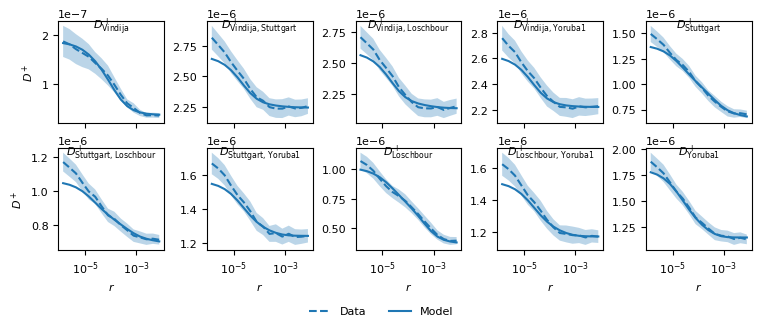

In [9]:
dpluspy.plotting.plot_D_plus_curves(
    models=model,
    pop_ids=data["pop_ids"], 
    bins=data["bins"], 
    means=data["means"], 
    varcovs=data["varcovs"], 
    ax_size=1.5,
    out="figures/deep_struc_fit_16.pdf",    
)


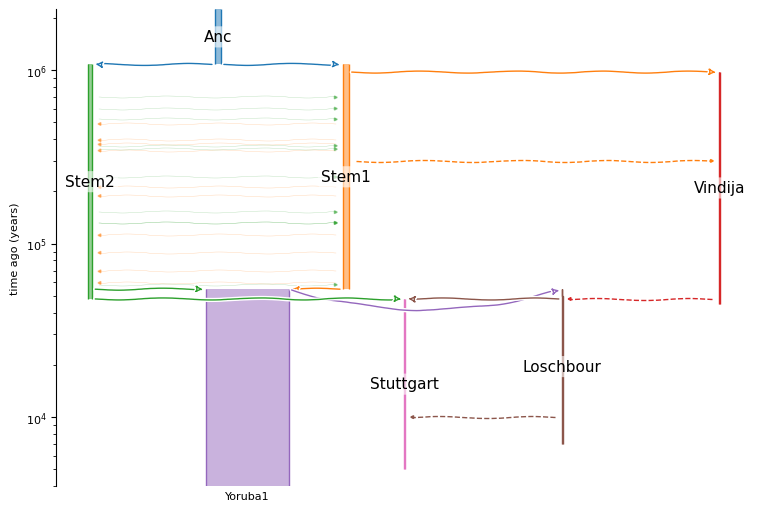

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 5), layout="constrained")
demesdraw.tubes(demes.load(graph), ax=ax, log_time=True, inf_ratio=0.05)
ax.set_ylim(4e3,)
plt.savefig("figures/deep_struc_fit_16_graph.pdf")

In [11]:
# Make a table of fitted parameters

dfs = []
param_file = "dummy_params.yaml"

for rep in range(30):
    graph_file = f"fitted_models/deep_struc_model_fit_{rep}.yaml"
    pnames, params = dpluspy.inference._load_params(graph_file, param_file)
    pdict = {"rep": rep}
    pdict.update({pname: [p] for pname, p in zip(pnames, params)})
    dfs.append(pandas.DataFrame(pdict))

param_df = pandas.concat(dfs)
param_df.to_csv("fitted_parameters.csv", index=False)
print(param_df.to_string(index=False))

 rep         T_12          T_HN         T_Yor        T_OOA        T_Bas        N_Anc          N_1          N_2       N_Vin         N_Yor       N_OOA       N_Los     m_12  p_H_N  p_N_OOA  p_LosStu   p_2Yor   p_2Bas
   0 1.544818e+06 774130.430379  87960.177090 50000.000000 19907.750415 12561.513454 13506.173843  5724.732652 2435.554433 251777.446347  916.310368 1225.195361 0.000022    0.2 0.022140  0.252785 0.175076 0.384798
   1 1.760026e+06 827778.415575  50256.450972 50256.450972 20724.942228 10787.234426 16230.906192  5534.911932 2447.879011 189889.172635  116.553779 1304.297771 0.000022    0.2 0.021374  0.264668 0.127304 0.394092
   2 1.092209e+06 955961.840962  66269.643414 50745.561561 21039.143611 13220.985106 11820.521467  9220.171800 2460.433449 150518.234998  105.657304 1511.980711 0.000009    0.2 0.021299  0.232126 0.330180 0.390723
   3 1.648163e+06 748443.051830  91286.643961 50000.000000 20158.441349 12426.943932 13019.791541  5690.688046 2431.819027 229981.372924 1158.37